# Lab 10: Fully Connected Neural Networks

In this assignment, we will learn fully connected neural network.


## 1. Example

This assignement should be run on Google Colab where you can use free GPU to accelerate the computation. Please refer to our slides to set up GPU.

### 1. Install Pytorch

In [1]:
!pip3 install torch torchvision   # install pytorch

### 2. Check GPU

In [2]:
!/opt/bin/nvidia-smi  #show GPU

Tue Apr 14 12:51:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 3. Mount to google drive (optional)

In [ ]:

from google.colab import drive
drive.mount('/content/gdrive')

### 4. Code

In [5]:
#Import Libraries
from __future__ import print_function
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable

In [6]:
args={}
args['batch_size']=100
args['test_batch_size']=100
args['epochs']=10  #The number of Epochs is the number of times you go through the full dataset.
args['lr']=0.01 #Learning rate is how fast it will decend.
args['log_interval']=10

In [7]:
# build an mlp
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(28*28, 256)   # linear layer (784 -> 256)
        self.fc2 = nn.Linear(256,128)  # linear layer (256 -> 128)
        self.fc3 = nn.Linear(128,10)  # linear layer (128 -> 10)

    def forward(self, x):
        h0 = x.view(-1,28*28) #input layer
        h1 = F.relu(self.fc1(h0)) # hidden layer 1
        h2 = F.relu(self.fc2(h1)) # hidden layer 2
        h3 = self.fc3(h2) # output layer

        return h3

model = Net()
model.cuda() # put the model on GPU
print(model)

Net(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [8]:
# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.SGD(model.parameters(),lr = args['lr'])

In [9]:
#load the data
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])),
    batch_size=args['batch_size'], shuffle=True)
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False, transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])),
    batch_size=args['test_batch_size'], shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.66MB/s]


In [10]:
def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.cuda(), target.cuda()

        output = model(data)
        loss = criterion(output, target)

        # compute gradients
        optimizer.zero_grad()
        loss.backward()

        #to do a one-step update on our parameter.
        optimizer.step()

        #Print out the loss periodically.
        if batch_idx % args['log_interval'] == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

In [11]:
def test():
    model.eval()
    test_loss = 0
    correct = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()

        output = model(data)
        test_loss += criterion(output, target).item() # sum up batch loss
        pred = output.data.max(1, keepdim=True)[1]
        correct += pred.eq(target.data.view_as(pred)).long().cpu().sum()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))


In [12]:
for epoch in range(1, args['epochs'] + 1):
    train(epoch)
    test()


Train Epoch: 1 [0/60000 (0%)]	Loss: 2.288222
Train Epoch: 1 [1000/60000 (2%)]	Loss: 2.254731
Train Epoch: 1 [2000/60000 (3%)]	Loss: 2.224730
Train Epoch: 1 [3000/60000 (5%)]	Loss: 2.196885
Train Epoch: 1 [4000/60000 (7%)]	Loss: 2.176301
Train Epoch: 1 [5000/60000 (8%)]	Loss: 2.152669
Train Epoch: 1 [6000/60000 (10%)]	Loss: 2.101255
Train Epoch: 1 [7000/60000 (12%)]	Loss: 2.036121
Train Epoch: 1 [8000/60000 (13%)]	Loss: 1.990459
Train Epoch: 1 [9000/60000 (15%)]	Loss: 1.876678
Train Epoch: 1 [10000/60000 (17%)]	Loss: 1.835038
Train Epoch: 1 [11000/60000 (18%)]	Loss: 1.757113
Train Epoch: 1 [12000/60000 (20%)]	Loss: 1.723963
Train Epoch: 1 [13000/60000 (22%)]	Loss: 1.629098
Train Epoch: 1 [14000/60000 (23%)]	Loss: 1.584854
Train Epoch: 1 [15000/60000 (25%)]	Loss: 1.409507
Train Epoch: 1 [16000/60000 (27%)]	Loss: 1.370012
Train Epoch: 1 [17000/60000 (28%)]	Loss: 1.344723
Train Epoch: 1 [18000/60000 (30%)]	Loss: 1.159337
Train Epoch: 1 [19000/60000 (32%)]	Loss: 1.250958
Train Epoch: 1 [200

## 2. Tasks

### 1. Please use other activation functions, e.g., sigmoid, tanh, and then plot the training loss and testing accuracy.

When plotting the training loss, the x-axis is iteration and the y-axis is training loss. When plotting the testing accuracy,  the x-axis is epoch and the y-axis is the training loss.

--- Running experiment with Sigmoid activation ---
Net_Sigmoid(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.297131
Train Epoch: 1 [1000/60000 (2%)]	Loss: 2.306522
Train Epoch: 1 [2000/60000 (3%)]	Loss: 2.289279
Train Epoch: 1 [3000/60000 (5%)]	Loss: 2.295508
Train Epoch: 1 [4000/60000 (7%)]	Loss: 2.284861
Train Epoch: 1 [5000/60000 (8%)]	Loss: 2.295903
Train Epoch: 1 [6000/60000 (10%)]	Loss: 2.305280
Train Epoch: 1 [7000/60000 (12%)]	Loss: 2.292265
Train Epoch: 1 [8000/60000 (13%)]	Loss: 2.300664
Train Epoch: 1 [9000/60000 (15%)]	Loss: 2.284618
Train Epoch: 1 [10000/60000 (17%)]	Loss: 2.288216
Train Epoch: 1 [11000/60000 (18%)]	Loss: 2.304744
Train Epoch: 1 [12000/60000 (20%)]	Loss: 2.282050
Train Epoch: 1 [13000/60000 (22%)]	Loss: 2.307884
Train Epoch: 1 [14000/60000 (23%)]	Loss: 2.293189
Train Epoch: 1 [15

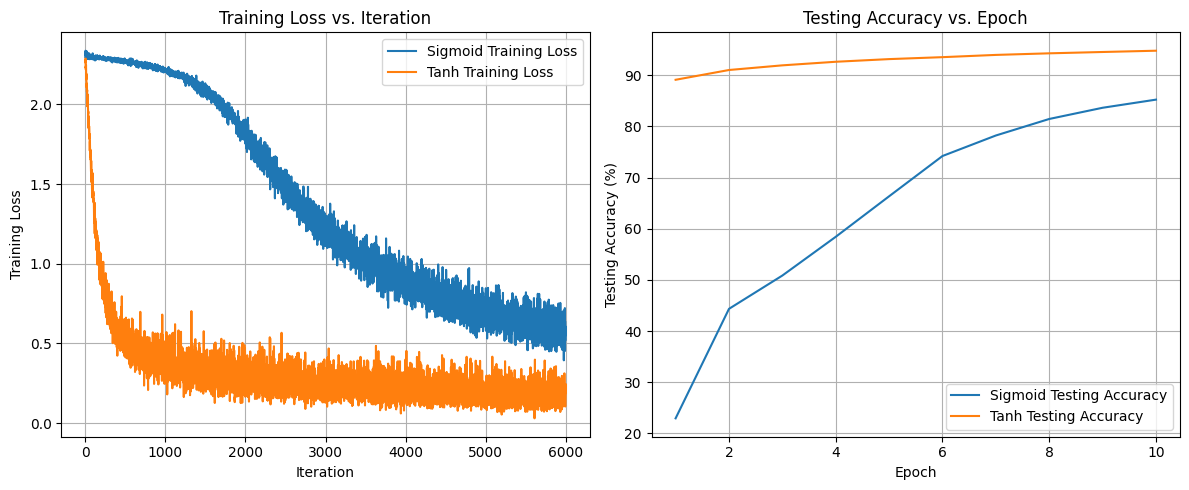

In [13]:
import matplotlib.pyplot as plt

class Net_Sigmoid(nn.Module):
    def __init__(self):
        super(Net_Sigmoid, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        h0 = x.view(-1, 28*28)
        h1 = torch.sigmoid(self.fc1(h0))
        h2 = torch.sigmoid(self.fc2(h1))
        h3 = self.fc3(h2)
        return h3

class Net_Tanh(nn.Module):
    def __init__(self):
        super(Net_Tanh, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        h0 = x.view(-1, 28*28)
        h1 = torch.tanh(self.fc1(h0))
        h2 = torch.tanh(self.fc2(h1))
        h3 = self.fc3(h2)
        return h3

def train_one_epoch(model, optimizer, criterion, epoch, train_loader, log_interval, train_losses_list):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.cuda(), target.cuda()

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_losses_list.append(loss.item())

        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

def test_one_epoch(model, criterion, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.cuda(), target.cuda()
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).long().cpu().sum()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset), accuracy))
    return accuracy, test_loss

def run_experiment(model_class, activation_name, args, train_loader, test_loader, criterion):
    print(f"--- Running experiment with {activation_name} activation ---")
    model = model_class()
    model.cuda()
    print(model)

    optimizer = torch.optim.SGD(model.parameters(), lr=args['lr'])

    train_losses = []
    test_accuracies = []

    for epoch in range(1, args['epochs'] + 1):
        train_one_epoch(model, optimizer, criterion, epoch, train_loader, args['log_interval'], train_losses)
        accuracy, _ = test_one_epoch(model, criterion, test_loader)
        test_accuracies.append(accuracy.item()) # Store accuracy for plotting

    return train_losses, test_accuracies, activation_name

sigmoid_train_losses, sigmoid_test_accuracies, _ = run_experiment(Net_Sigmoid, "Sigmoid", args, train_loader, test_loader, criterion)
tanh_train_losses, tanh_test_accuracies, _ = run_experiment(Net_Tanh, "Tanh", args, train_loader, test_loader, criterion)


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(len(sigmoid_train_losses)), sigmoid_train_losses, label='Sigmoid Training Loss')
plt.plot(range(len(tanh_train_losses)), tanh_train_losses, label='Tanh Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('Training Loss vs. Iteration')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
epochs_range = range(1, args['epochs'] + 1)
plt.plot(epochs_range, sigmoid_test_accuracies, label='Sigmoid Testing Accuracy')
plt.plot(epochs_range, tanh_test_accuracies, label='Tanh Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Testing Accuracy (%)')
plt.title('Testing Accuracy vs. Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 2. Please use different layers in the model, e.g., 1 layer, 5 layers, 10 layers,  and then plot the training loss and testing accuracy.

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.95MB/s]



--- Running experiment with 1 layer(s) ---
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.381711
Train Epoch: 1 [1000/60000 (2%)]	Loss: 1.511916
Train Epoch: 1 [2000/60000 (3%)]	Loss: 1.176610
Train Epoch: 1 [3000/60000 (5%)]	Loss: 0.960996
Train Epoch: 1 [4000/60000 (7%)]	Loss: 0.805781
Train Epoch: 1 [5000/60000 (8%)]	Loss: 0.796331
Train Epoch: 1 [6000/60000 (10%)]	Loss: 0.861169
Train Epoch: 1 [7000/60000 (12%)]	Loss: 0.891891
Train Epoch: 1 [8000/60000 (13%)]	Loss: 0.702702
Train Epoch: 1 [9000/60000 (15%)]	Loss: 0.641850
Train Epoch: 1 [10000/60000 (17%)]	Loss: 0.663719
Train Epoch: 1 [11000/60000 (18%)]	Loss: 0.629295
Train Epoch: 1 [12000/60000 (20%)]	Loss: 0.662858
Train Epoch: 1 [13000/60000 (22%)]	Loss: 0.537117
Train Epoch: 1 [14000/60000 (23%)]	Loss: 0.528960
Train Epoch: 1 [15000/60000 (25%)]	Loss: 0.467870
Train Epoch: 1 [16000/60000 (27%)]	Loss: 0.423602
Train Epoch: 1 [17000/60000 (28%)]	Loss: 0.445970
Train Epoch: 1 [18000/60000 (30%)]	Loss: 0.517079
Train Epoch: 1 [19000/600

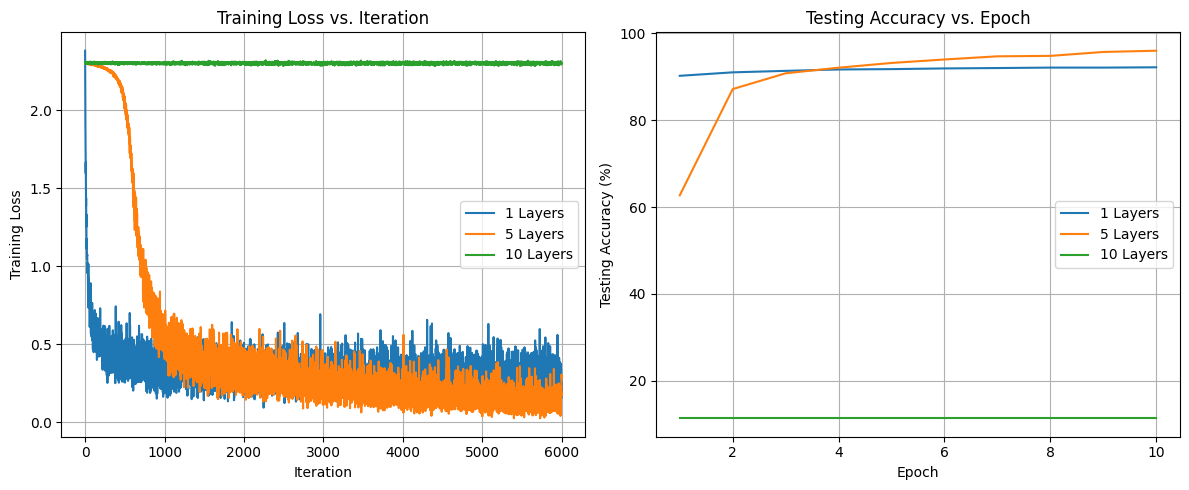

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

args = {'batch_size': 100, 'test_batch_size': 100, 'epochs': 10, 'lr': 0.01, 'log_interval': 10}

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])),
    batch_size=args['batch_size'], shuffle=True)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False, transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])),
    batch_size=args['test_batch_size'], shuffle=False)

criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, optimizer, criterion, epoch, train_loader, log_interval, train_losses_list):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.cuda(), target.cuda()
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_losses_list.append(loss.item())
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

def test_one_epoch(model, criterion, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.cuda(), target.cuda()
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).long().cpu().sum()
    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset), accuracy))
    return accuracy, test_loss

class DynamicNet(nn.Module):
    def __init__(self, num_layers):
        super(DynamicNet, self).__init__()
        self.num_layers = num_layers
        self.layers = nn.ModuleList()

        if num_layers == 1:
            self.layers.append(nn.Linear(28*28, 10))
        else:
            self.layers.append(nn.Linear(28*28, 256))
            for _ in range(num_layers - 2):
                self.layers.append(nn.Linear(256, 256))
            self.layers.append(nn.Linear(256, 10))

    def forward(self, x):
        h = x.view(-1, 28*28)
        for i in range(self.num_layers - 1):
            h = F.relu(self.layers[i](h))
        h = self.layers[-1](h)
        return h

def run_depth_experiment(num_layers, args, train_loader, test_loader, criterion):
    print(f"\n--- Running experiment with {num_layers} layer(s) ---")
    model = DynamicNet(num_layers)
    model.cuda()

    optimizer = torch.optim.SGD(model.parameters(), lr=args['lr'])

    train_losses = []
    test_accuracies = []

    for epoch in range(1, args['epochs'] + 1):
        train_one_epoch(model, optimizer, criterion, epoch, train_loader, args['log_interval'], train_losses)
        accuracy, _ = test_one_epoch(model, criterion, test_loader)
        test_accuracies.append(accuracy.item())

    return train_losses, test_accuracies, f"{num_layers} Layers"

loss_1, acc_1, label_1 = run_depth_experiment(1, args, train_loader, test_loader, criterion)
loss_5, acc_5, label_5 = run_depth_experiment(5, args, train_loader, test_loader, criterion)
loss_10, acc_10, label_10 = run_depth_experiment(10, args, train_loader, test_loader, criterion)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(len(loss_1)), loss_1, label=label_1)
plt.plot(range(len(loss_5)), loss_5, label=label_5)
plt.plot(range(len(loss_10)), loss_10, label=label_10)
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('Training Loss vs. Iteration')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
epochs_range = range(1, args['epochs'] + 1)
plt.plot(epochs_range, acc_1, label=label_1)
plt.plot(epochs_range, acc_5, label=label_5)
plt.plot(epochs_range, acc_10, label=label_10)
plt.xlabel('Epoch')
plt.ylabel('Testing Accuracy (%)')
plt.title('Testing Accuracy vs. Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()